# Flynn: reduce integer discontinuities

Can shifting an entire region by one turn reduce the number of costly jumps?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

Represent a candidate as $u=w+2\pi n$ (up to the implementation’s phase origin).
For an edge, the integer discrepancy from its shortest wrapped step is
$k_{ab}=\operatorname{round}((u_b-u_a-W(w_b-w_a))/(2\pi))$.
A minimum-discontinuity model penalizes $\sum c_{ab}|k_{ab}|$.

1. Initialize integer jumps from the wrapped input.
2. Sweep the padded network in four directions, propagating possible improvements.
3. Use detected improving paths/loops to change integer discontinuities.
4. Repeat until a sweep cannot add an improving edge, then reconstruct the phase.

On a chain $w=(2.8,-2.9,-2.3)$, shifting the last two pixels together by $2\pi$
removes the first jump without changing the difference inside that region.

Initial labels integer edge discrepancies: [-1  0] L1 total: 1
Shift region {1,2} by one turn integer edge discrepancies: [0 0] L1 total: 0


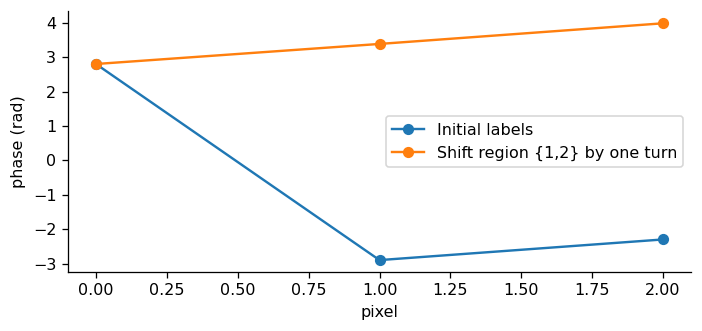

In [2]:
w=np.array([2.8,-2.9,-2.3]); candidates=[w,w+2*np.pi*np.array([0,1,1])]
fig,ax=plt.subplots(figsize=(7,3))
for u,label in zip(candidates,['Initial labels','Shift region {1,2} by one turn']):
    ax.plot(u,'o-',label=label)
    k=np.rint((np.diff(u)-W(np.diff(w)))/(2*np.pi)).astype(int)
    print(label,'integer edge discrepancies:',k,'L1 total:',np.abs(k).sum())
ax.set(xlabel='pixel',ylabel='phase (rad)'); ax.legend(); plt.show()

## 2 · Read the calculation

Changing a whole connected region preserves its internal gradients and changes
only its boundary. The chain illustrates why region moves can improve an answer
when isolated pixel changes would introduce new jumps. The full Flynn routine
uses its own network sweeps, not the three-pixel enumeration above.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

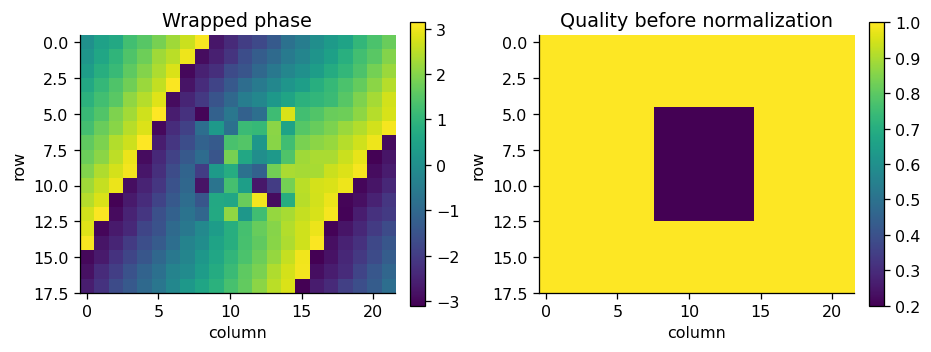

Network sweeps: 8


| Quantity | Measured value |
|---|---|
| Aligned RMSE (rad) | 0.455811 |
| Raw max wrapped difference from input (rad) | 3.141593 |

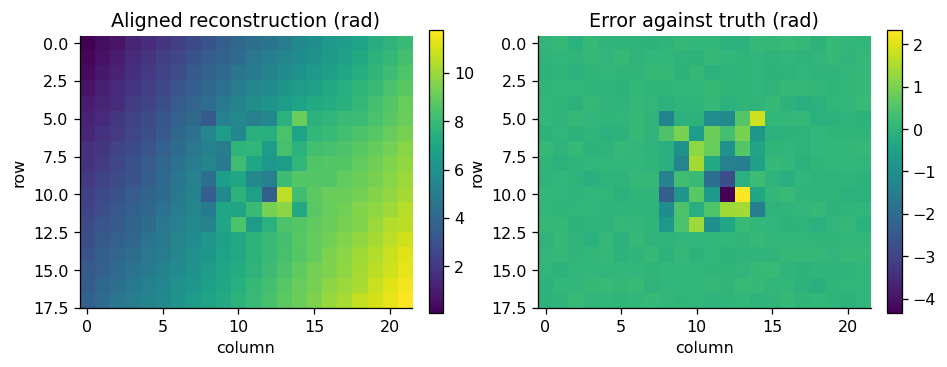

In [3]:
truth,phase,confidence=scene()
u,iterations=pv.flynn_unwrap(phase,quality=confidence,return_iterations=True)
images([phase,confidence],['Wrapped phase','Quality before normalization'])
print('Network sweeps:',iterations); report(u,truth,phase)

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

In [4]:
rows=[]
for name,q in [('Uniform',None),('Patch confidence',confidence)]:
    u,it=pv.flynn_unwrap(phase,quality=q,return_iterations=True)
    rows.append([name,it,f'{pv.rmse_aligned(u,truth):.4f}'])
table(['Quality','Sweeps','Aligned RMSE'],rows)

| Quality | Sweeps | Aligned RMSE |
|---|---|---|
| Uniform | 8 | 0.4558 |
| Patch confidence | 8 | 0.4558 |

## 5 · Interpretation and limits

Quality is linearly rescaled to [0,1], so it is not an absolute inverse variance.
The implementation retains integer costs and float32 cycle arithmetic. As with
the branch-cut routines, the phase-origin offset is visible in the raw wrapping
metric; compare gradients and aligned errors as well. The API requires 2-D input.
An iteration count describes work performed, not a certificate of physical truth.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`flynn.py`](../src/parvaneh/flynn.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.